In [1]:
import os
import project_functions as pf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#pf.fetch_data()

In [3]:
def load_data_set(housing_path = pf.HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [4]:
housing = load_data_set()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


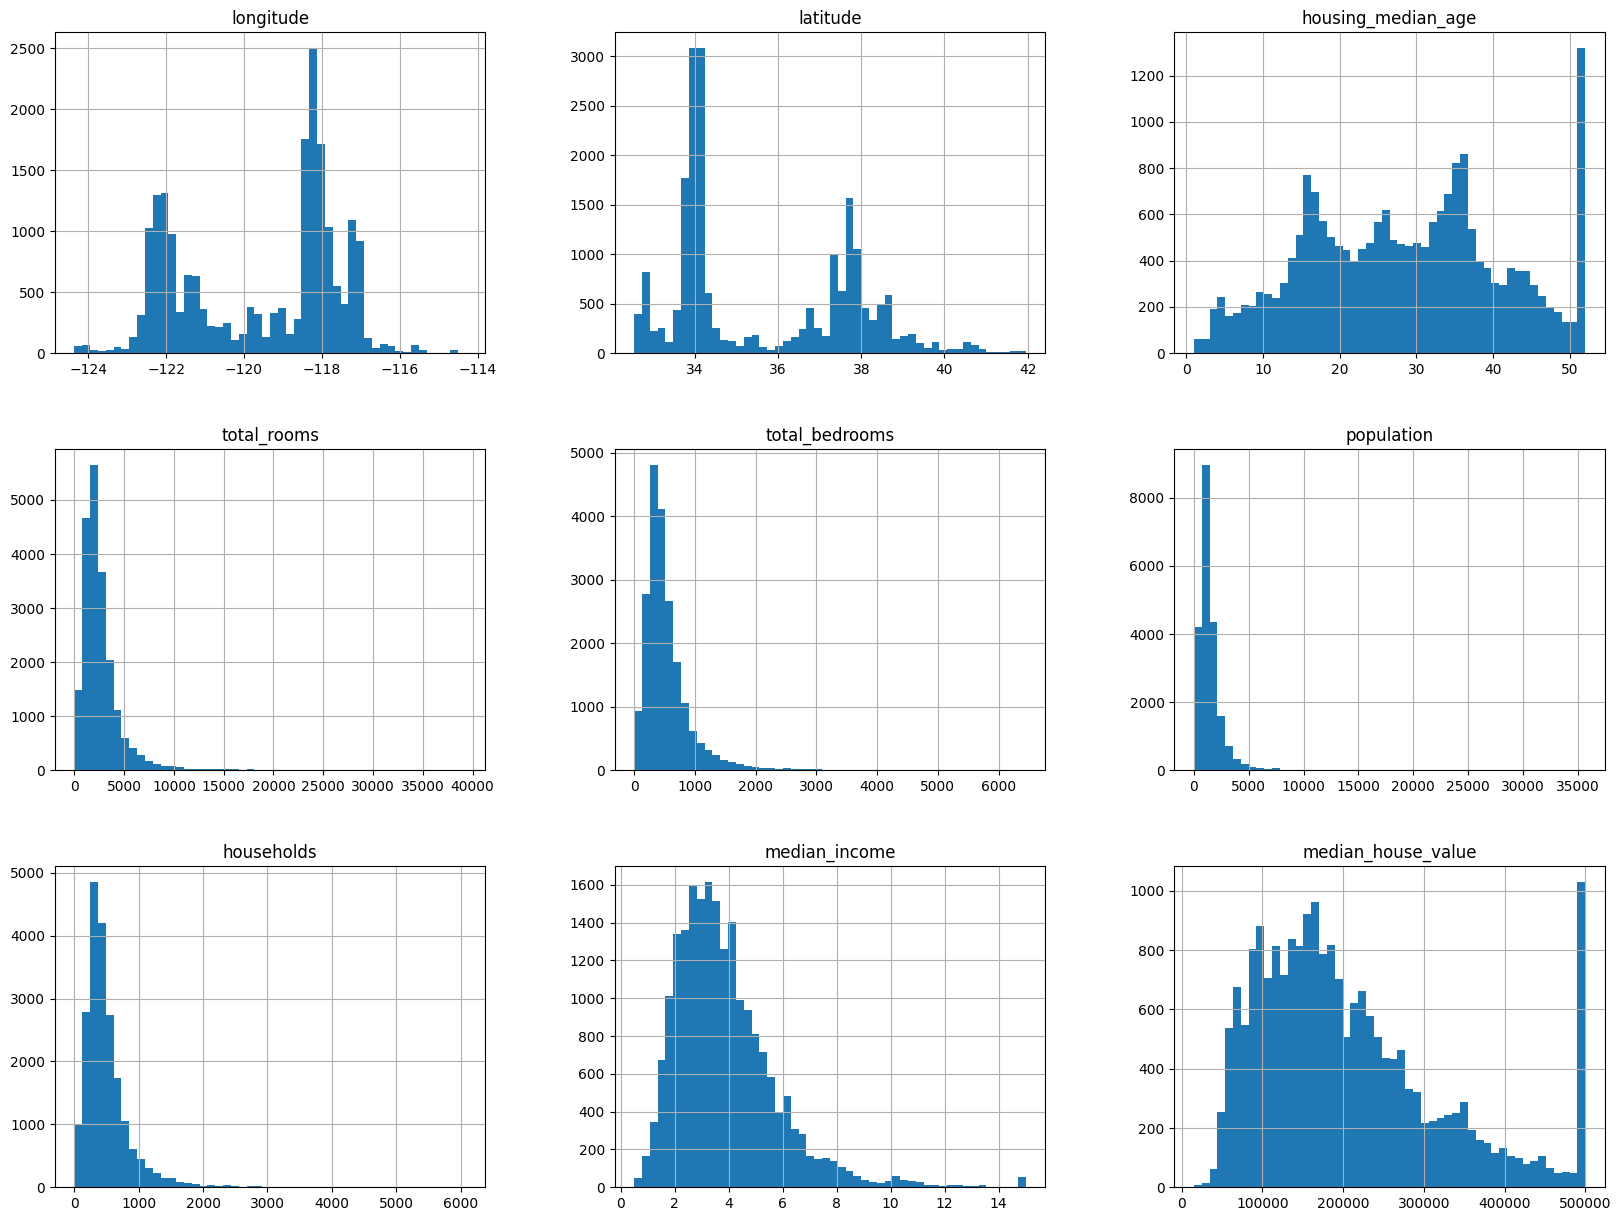

In [8]:
housing.hist(bins = 50, figsize = (20,15))
plt.show()

In [9]:
def split_train_test(data, test_ratio):
    np.random.seed(42) # this ensures that every time same permutation is generated
    shuffled_indices = np.random.permutation(len(data)) # it produces new train and test every time executed
    test_size = int(len(shuffled_indices) * test_ratio)
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]
    return data.iloc[train_indices] , data.iloc[test_indices]
train , test = split_train_test(housing, 0.2)  # but both will break if updated data is fetched 
test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


In [10]:
from zlib import crc32
def test_set_check(identifier, test_ratio):
 return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32 # check the id is in a <= 20% or not

In [11]:
def split_train_test_by_id(data, test_ratio, id_column):
    ids =  data[id_column]
    is_in_test = ids.apply(lambda id_ : test_set_check(id_, test_ratio)) 
    # is_in_test -> a series of True/False value corresponding to the ids

    return data.iloc[~is_in_test] , data.iloc[is_in_test] # train, test

In [12]:
housing_with_id = housing.reset_index()
train_split, test_split = split_train_test_by_id(housing_with_id, 0.2,"index") 
# using index column as unique identifier, but if any row delete or added in b/w it can cause inconsistency
test_split.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
16,16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY


In [13]:
housing_with_id["id"] = housing_with_id["longitude"] * 1000 + housing_with_id["latitude"] 
train_split, test_split = split_train_test_by_id(housing_with_id, 0.2,"id") 
# using latitude and longitude as column as unique identifier,as these are always unique and constant for each ite,
test_split.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
59,59,-122.29,37.82,2.0,158.0,43.0,94.0,57.0,2.5625,60000.0,NEAR BAY,-122252.18
60,60,-122.29,37.83,52.0,1121.0,211.0,554.0,187.0,3.3929,75700.0,NEAR BAY,-122252.17
61,61,-122.29,37.82,49.0,135.0,29.0,86.0,23.0,6.1183,75000.0,NEAR BAY,-122252.18
62,62,-122.29,37.81,50.0,760.0,190.0,377.0,122.0,0.9011,86100.0,NEAR BAY,-122252.19
67,67,-122.29,37.80,52.0,1027.0,244.0,492.0,147.0,2.6094,81300.0,NEAR BAY,-122252.20


In [14]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size = 0.2 , random_state = 42)
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


<Axes: >

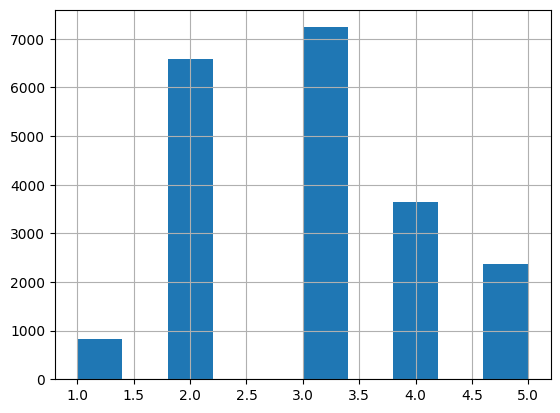

In [15]:
housing["income_cat"] = pd.cut(housing["median_income"],
                                bins = [0.0, 1.5, 3.0, 4.5, 6.0, np.inf], # i.e. 0-1.5 -> less tha $15,000
                               labels = [1,2,3,4,5])
housing["income_cat"].hist()

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit
# splits in such way that test set represent the overall dataset
data_split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_index, test_index in data_split.split(housing,housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [17]:
## calculating error % of sampling
random_test_set = test_set.copy()
random_test_set["income_cat"] = pd.cut(random_test_set["median_income"],
                                bins = [0.0, 1.5, 3.0, 4.5, 6.0, np.inf], # i.e. 0-1.5 -> less tha $15,000
                               labels = [1,2,3,4,5])

strat_test_set_sampling = strat_test_set["income_cat"].value_counts() / len(strat_test_set)

ramdom_sampling = random_test_set["income_cat"].value_counts() / len(random_test_set)

overall_sampling = housing["income_cat"].value_counts() / len(housing)

strat_error = ((overall_sampling - strat_test_set_sampling) / overall_sampling) * 100 
print("Strat sampling error %")
print(strat_error)

random_error = ((overall_sampling - ramdom_sampling) / overall_sampling) * 100 
print("Random sampling error %")
print(random_error)

Strat sampling error %
income_cat
3    0.013820
2    0.015195
4   -0.027480
5    0.084674
1   -0.364964
Name: count, dtype: float64
Random sampling error %
income_cat
3   -2.266446
2   -1.732260
4    5.056334
5    4.318374
1   -0.973236
Name: count, dtype: float64


In [18]:
# remoce the income_cat from data, back to og
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis = 1, inplace = True)

In [19]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

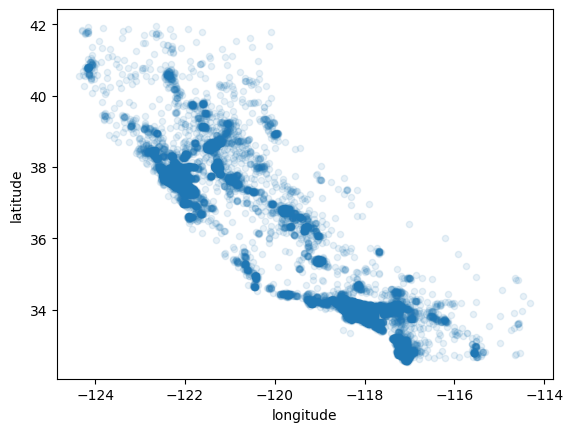

In [21]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", alpha = 0.1)

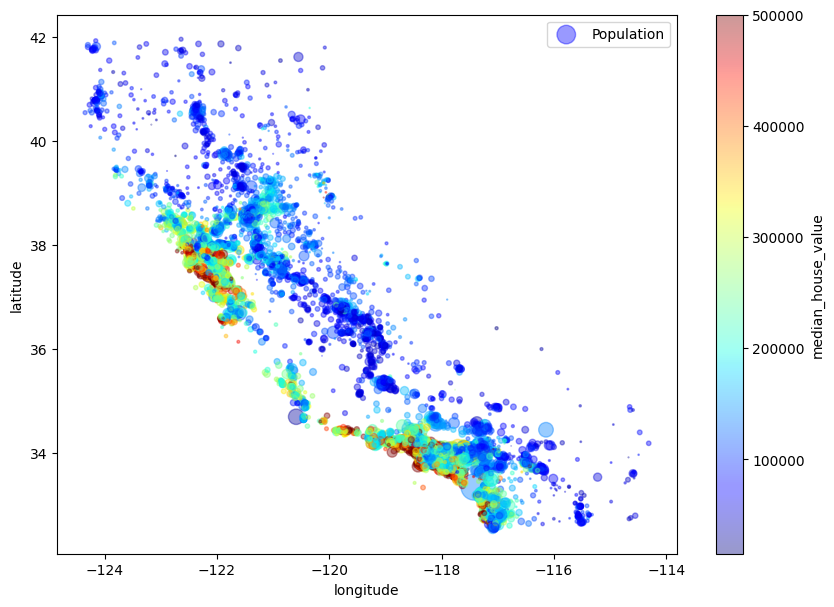

In [24]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", alpha = 0.4,
            s = housing["population"]/100, label = "Population", figsize = (10,7),
            c = "median_house_value", cmap = plt.get_cmap("jet"), colorbar = True)
plt.legend()
plt.show()

In [30]:
# Looking for correlations
# standard correlation coefficient / Pearson's r
housing_copy = housing.copy()
housing_copy = housing_copy.drop(columns=["ocean_proximity"]) 
corr_matrix = housing_copy.corr()
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

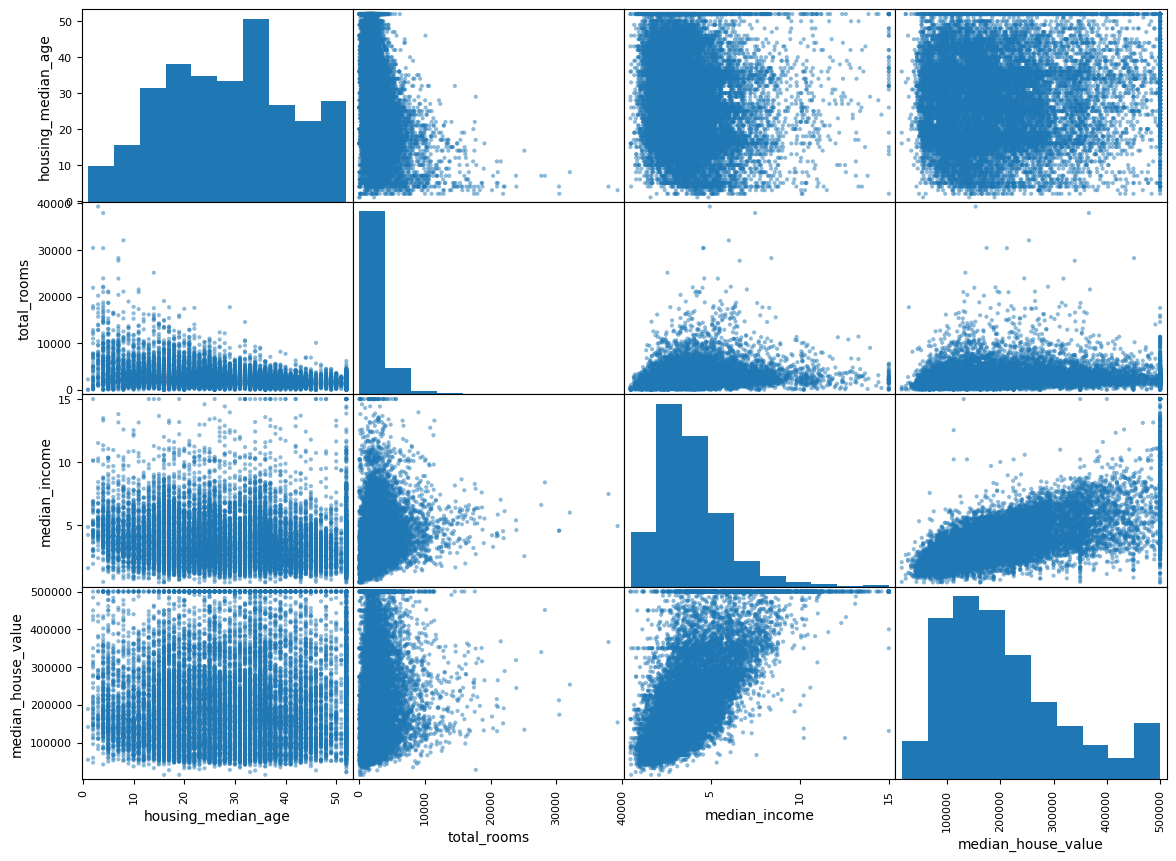

In [35]:
from pandas.plotting import scatter_matrix # plot every numerical values against other numerical values
attributes = ["housing_median_age", "total_rooms", "median_income", "median_house_value"]
scatter_matrix(housing[attributes], figsize = (14, 10))
plt.show()

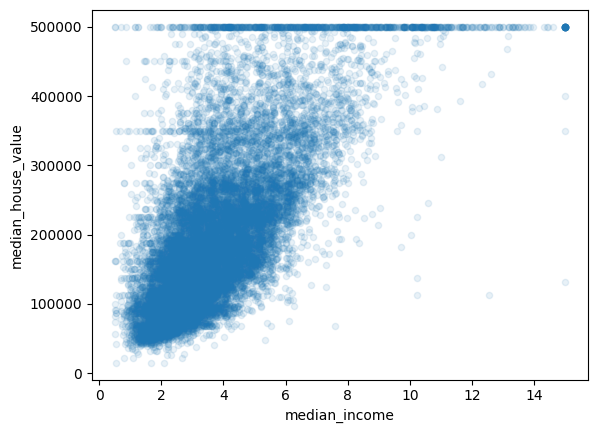

In [37]:
# most promising correlation with median house price is median income
housing.plot(kind = "scatter", x = "median_income" , y = "median_house_value", alpha = 0.1)
plt.show()

In [40]:
# we can try finding correations with different combinations of attriutes
housing_copy["rooms_per_households"] =  housing_copy["total_rooms"] / housing_copy["households"]
housing_copy["bedrooms_per_room"] =  housing_copy["total_bedrooms"] / housing_copy["total_rooms"]
housing_copy["population_per_households"] =  housing_copy["population"] / housing_copy["households"]

corr_matrix = housing_copy.corr()
corr_matrix["median_house_value"].sort_values(ascending = False)


median_house_value           1.000000
median_income                0.687151
rooms_per_households         0.146255
total_rooms                  0.135140
housing_median_age           0.114146
households                   0.064590
total_bedrooms               0.047781
population_per_households   -0.021991
population                  -0.026882
longitude                   -0.047466
latitude                    -0.142673
bedrooms_per_room           -0.259952
Name: median_house_value, dtype: float64

In [41]:
# new attribute rooms_per_households is highly correlated eith median house price